# ¿Cuántas horas debe dormir tu cuerpo?

Te dijeron que **8 horas**. Pero tus órganos no envejecen al mismo ritmo, y la cifra que aparece en sus datos es otra.

Un equipo combinó **23 relojes biológicos** (MRI cerebrales, marcadores en sangre, perfiles metabólicos) sobre **una cohorte del UK Biobank** y miró qué pasa con la edad biológica de cada órgano según las horas que la persona dice dormir.

Aquí descargamos las curvas que publicaron y miramos qué hay debajo del titular.

📄 **Paper:** [Sleep chart of biological ageing clocks in middle and late life](https://doi.org/10.1038/s41586-026-10524-5) · *Nature*
📊 **Datos:** [Zenodo (CC-BY 4.0)](https://doi.org/10.5281/zenodo.17409425)
🎬 **Video:** [Pendiente]

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-13-sueno-relojes-biologicos-edad/notebook.ipynb)


## Qué midieron

El UK Biobank tiene a medio millón de personas con seguimiento clínico y genético. De ahí los autores sacaron una sub-cohorte entre 37 y 84 años y le aplicaron **tres lentes distintas** para estimar edad biológica órgano por órgano:

- **MRI** — imagen de 7 órganos (forma, volumen, intensidad).
- **Proteómica plasmática** — proteínas en sangre asociadas a 11 órganos.
- **Metabolómica** — perfiles de metabolitos de 5 órganos.

Cada combinación órgano × ómica × sexo es un *reloj*. En total: **23 relojes × 2 sexos = 46 curvas**.

Lo que publican es el **gap de edad biológica** (cuánto se aparta la edad del órgano de la edad cronológica) en función de **horas de sueño auto-reportadas**.

> **Asociación, no causa.** El paper lo dice literalmente: la randomización mendeliana *no descartó causalidad inversa*. Que tu reloj de hígado sume años no implica que dormir mal lo haya envejecido — puede que el órgano envejecido sea el que cambia el sueño.


In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
HORAS_TITULAR = 8.0          # las "8 horas" del consejo popular
RANGO_PAPER_MIN = 6.4        # límite inferior del rango óptimo del paper
RANGO_PAPER_MAX = 7.8        # límite superior del rango óptimo del paper
FUENTE = "Fuente: Wen et al. (2026), Nature | Datos: Zenodo 10.5281/zenodo.17409425"

COLOR_DATOS = "#2563EB"      # azul CaM — distribuciones / datos principales
COLOR_ALERTA = "#DC2626"     # rojo — referencia "8h"
COLOR_SECUNDARIO = "#059669" # emerald — Proteómica
COLOR_AMBAR = "#D97706"      # amber — Metabolómica
COLOR_VIOLETA = "#7C3AED"    # MRI
COLOR_GRIS = "#BBBBBB"       # contexto

# ══════════════════════════════════════════════════════════════
# Setup
# ══════════════════════════════════════════════════════════════
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Estilo CaM (local → fallback GitHub raw)
style_file = "../../cam.mplstyle"
if not os.path.exists(style_file):
    style_file = "/tmp/cam.mplstyle"
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle", style_file,
        )
plt.style.use(style_file)

# Crear directorio de figuras
os.makedirs("figuras", exist_ok=True)

# ══════════════════════════════════════════════════════════════
# Carga de datos
# ══════════════════════════════════════════════════════════════
curvas = pd.read_csv("datos/curvas_u_sueno_edad.csv")
optimos = pd.read_csv("datos/optimo_sueno_por_organo.csv")

print(f"Curvas modeladas: {curvas.shape[0]:,} puntos sobre {curvas[['organo','tecnologia','sexo']].drop_duplicates().shape[0]} combinaciones órgano×ómica×sexo")
print(f"Órganos únicos:   {curvas['organo'].nunique()} ({', '.join(sorted(curvas['organo'].unique())[:6])}...)")
print(f"Tecnologías:      {', '.join(sorted(curvas['tecnologia'].unique()))}")
print(f"Combinaciones con U clara (óptimo interior 4.5–9.5 h): {int(optimos['curva_U_interior'].sum())} de {len(optimos)}")


Curvas modeladas: 4,600 puntos sobre 46 combinaciones órgano×ómica×sexo
Órganos únicos:   18 (Adipose, Brain, Digestive, Endocrine, Eye, Heart...)
Tecnologías:      MRI, Met, Prot
Combinaciones con U clara (óptimo interior 4.5–9.5 h): 37 de 46


## Aquí está.

Las 37 curvas U que tienen óptimo claro (no clavado en el borde del rango modelado) — empezando por el cerebro, donde las dos lentes (MRI y proteómica) discrepan.


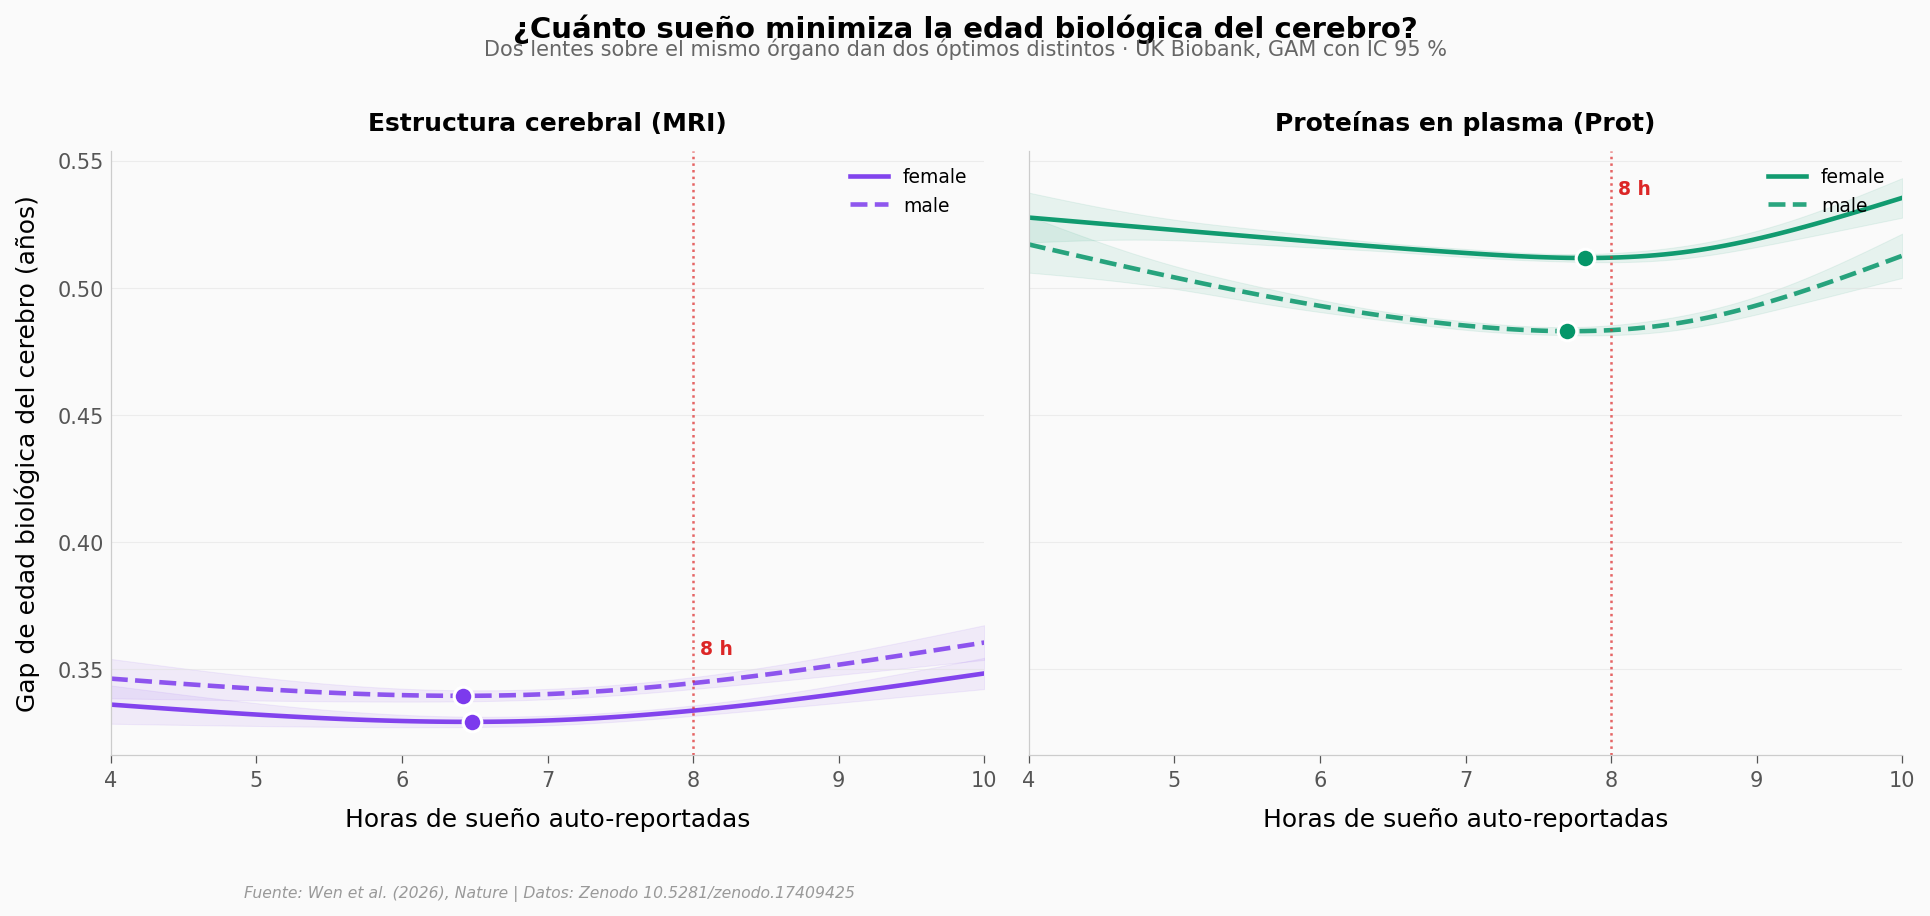


Óptimos del cerebro:
  MRI   female: 6.48 h
  MRI   male  : 6.42 h
  Prot  female: 7.82 h
  Prot  male  : 7.70 h


In [2]:
# Gráfica hero — cerebro visto por dos lentes
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)

panel_specs = [
    ("MRI",  "Estructura cerebral (MRI)",   COLOR_VIOLETA),
    ("Prot", "Proteínas en plasma (Prot)",  COLOR_SECUNDARIO),
]

for ax, (tech, titulo, color_tech) in zip(axes, panel_specs):
    sub = curvas[(curvas["organo"]=="Brain") & (curvas["tecnologia"]==tech)]
    for sexo, ls, alpha in [("female","-",0.95), ("male","--",0.85)]:
        s = sub[sub["sexo"]==sexo].sort_values("horas_sueno")
        ax.plot(s["horas_sueno"], s["edad_biol_gap"], color=color_tech,
                linewidth=2.2, linestyle=ls, alpha=alpha, label=sexo)
        ax.fill_between(s["horas_sueno"], s["gap_ci_inferior"], s["gap_ci_superior"],
                        color=color_tech, alpha=0.08)
        # Marcar el óptimo individual
        opt_row = optimos[(optimos["organo"]=="Brain") & (optimos["tecnologia"]==tech) & (optimos["sexo"]==sexo)].iloc[0]
        ax.scatter([opt_row["horas_optimo"]], [opt_row["gap_minimo"]],
                   color=color_tech, s=80, zorder=6,
                   edgecolors="white", linewidths=1.5)

    # Línea de referencia "8h"
    ax.axvline(HORAS_TITULAR, color=COLOR_ALERTA, linewidth=1.2,
               linestyle=":", alpha=0.7)
    ax.text(HORAS_TITULAR+0.05, ax.get_ylim()[1]*0.98, "8 h",
            color=COLOR_ALERTA, fontsize=9, fontweight="bold", va="top")

    ax.set_xlabel("Horas de sueño auto-reportadas")
    ax.set_title(titulo, fontsize=12, fontweight="bold", pad=10)
    ax.legend(fontsize=9, loc="upper right", framealpha=0.9)
    ax.set_xlim(4, 10)

axes[0].set_ylabel("Gap de edad biológica del cerebro (años)")

fig.suptitle("¿Cuánto sueño minimiza la edad biológica del cerebro?",
             fontsize=14, fontweight="bold", y=1.02)
fig.text(0.5, 0.97, "Dos lentes sobre el mismo órgano dan dos óptimos distintos · UK Biobank, GAM con IC 95 %",
         fontsize=10, color="#666666", ha="center")
fig.text(0.13, -0.05, FUENTE, fontsize=7.5, color="#999999", style="italic")

plt.tight_layout()
plt.savefig("figuras/01_brain_dos_lentes.png", dpi=200, bbox_inches="tight")
plt.show()

# Imprimir óptimos para verificación
print("\nÓptimos del cerebro:")
for _, r in optimos[optimos["organo"]=="Brain"].iterrows():
    print(f"  {r['tecnologia']:5} {r['sexo']:6}: {r['horas_optimo']:.2f} h")


## La discrepancia entre lentes

Mirado por **resonancia magnética**, el cerebro tiene su menor gap de edad cuando la persona duerme alrededor de **6.4 h**. Mirado por **proteínas en plasma** sobre las mismas personas, el óptimo se mueve hasta **7.7–7.8 h**. Diferencia: cerca de **1,3 horas**.

No es un error del método — es que cada ómica captura otro nivel: la estructura física del órgano no envejece al ritmo de la firma proteica que circula por la sangre. Las dos pueden ser ciertas a la vez.

El sexo apenas mueve la aguja dentro de cada lente. La discrepancia importante está entre ómicas, no entre hombres y mujeres.


## Ampliar el zoom

Si el cerebro ya muestra que el óptimo depende de qué se mide, ¿qué pasa cuando juntamos los 18 órganos?


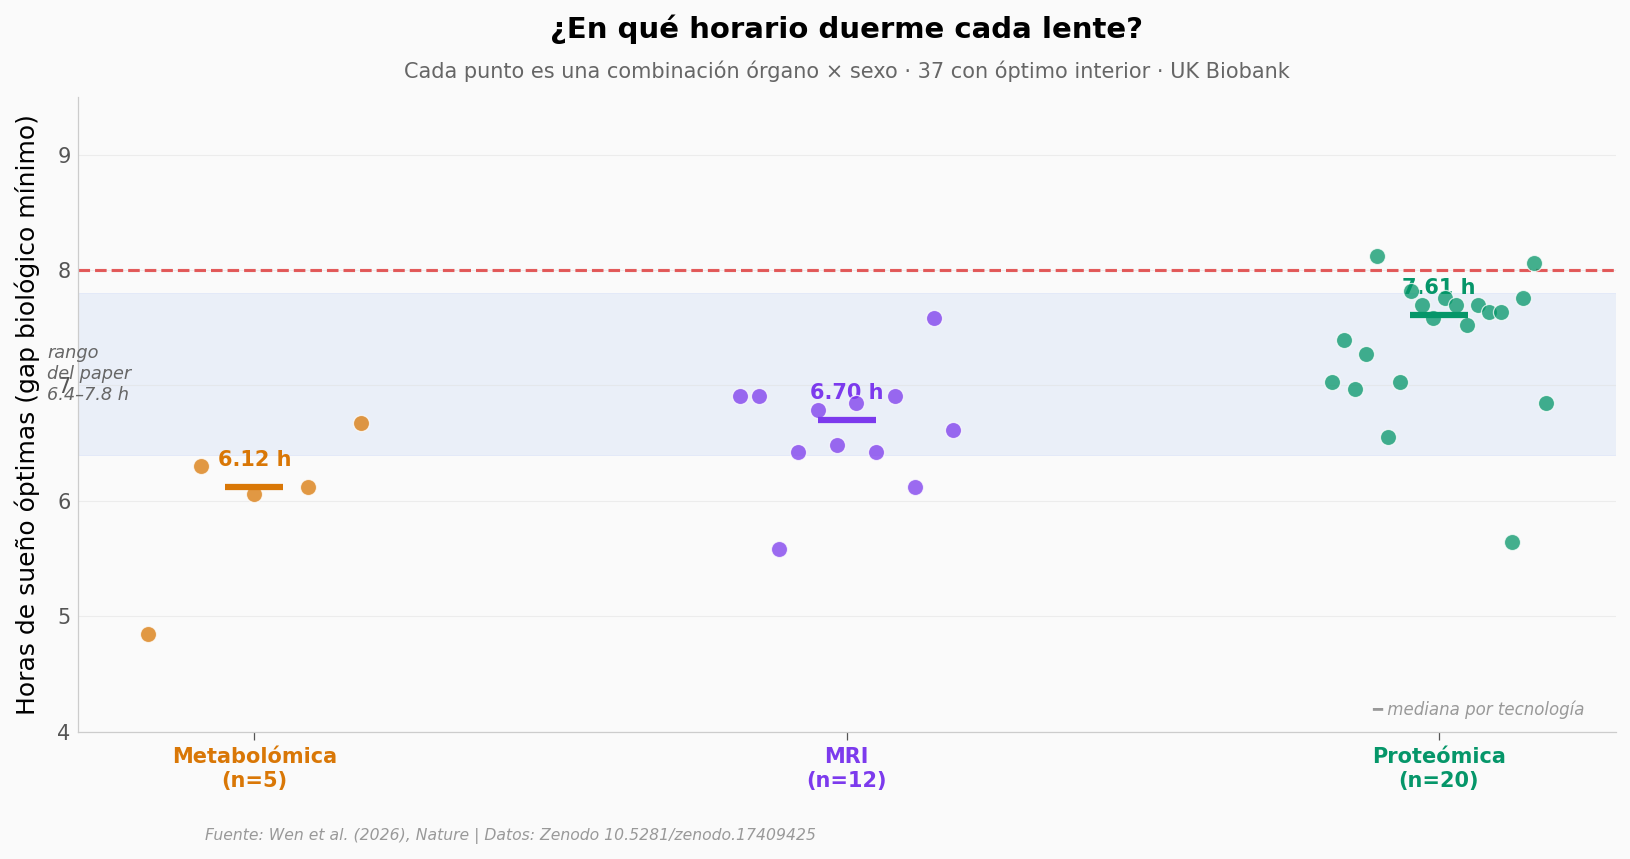


Medianas por tecnología:
  Met : 6.12 h (n=5)
  MRI : 6.70 h (n=12)
  Prot: 7.61 h (n=20)


In [3]:
# Distribución de óptimos por tecnología (solo curvas con U interior)
df_u = optimos[optimos["curva_U_interior"]==True].copy()

fig, ax = plt.subplots(figsize=(11, 5.5))

# Strip plot por tecnología con jitter reproducible
np.random.seed(42)
tech_order = ["Met", "MRI", "Prot"]
tech_colors = {"MRI": COLOR_VIOLETA, "Prot": COLOR_SECUNDARIO, "Met": COLOR_AMBAR}
positions = [0, 1, 2]

medianas = []
for pos, tech in zip(positions, tech_order):
    vals = df_u[df_u["tecnologia"]==tech]["horas_optimo"].values
    n = len(vals)
    if n == 0:
        continue
    x_strip = np.linspace(pos - 0.18, pos + 0.18, n)
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals, color=tech_colors[tech], s=60, alpha=0.75,
               edgecolors="white", linewidths=0.6, zorder=5)
    mediana = float(np.median(vals))
    medianas.append((pos, mediana, tech, n))
    ax.errorbar(pos, mediana, yerr=0, fmt="_", color=tech_colors[tech],
                markersize=28, markeredgewidth=3, zorder=6)
    ax.text(pos, mediana + 0.18, f"{mediana:.2f} h",
            color=tech_colors[tech], fontsize=10, fontweight="bold",
            ha="center")

# Línea "8 h"
ax.axhline(HORAS_TITULAR, color=COLOR_ALERTA, linewidth=1.5, linestyle="--", alpha=0.75)
ax.annotate("'8 horas' del consejo popular",
            xy=(2.4, HORAS_TITULAR), xytext=(2.45, 9.0),
            fontsize=10, fontweight="bold", color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle="->", color=COLOR_ALERTA, lw=1.3))

# Banda del rango del paper
ax.axhspan(RANGO_PAPER_MIN, RANGO_PAPER_MAX, color=COLOR_DATOS, alpha=0.07, zorder=1)
ax.text(-0.35, (RANGO_PAPER_MIN+RANGO_PAPER_MAX)/2, "rango\ndel paper\n6.4–7.8 h",
        fontsize=8.5, color="#666666", style="italic", ha="left", va="center")

ax.set_xticks(positions)
ax.set_xticklabels(["Metabolómica\n(n=5)", "MRI\n(n=12)", "Proteómica\n(n=20)"],
                   fontsize=10, fontweight="bold")
for tick, tech in zip(ax.get_xticklabels(), tech_order):
    tick.set_color(tech_colors[tech])

ax.set_ylabel("Horas de sueño óptimas (gap biológico mínimo)")
ax.set_ylim(4, 9.5)
ax.set_title("¿En qué horario duerme cada lente?", fontsize=14, fontweight="bold", pad=28)
ax.text(0.5, 1.03, "Cada punto es una combinación órgano × sexo · 37 con óptimo interior · UK Biobank",
        transform=ax.transAxes, fontsize=10, color="#666666", ha="center")
ax.text(0.98, 0.02, "━ mediana por tecnología", transform=ax.transAxes,
        fontsize=8, color="#999999", ha="right", va="bottom", style="italic")
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color="#999999", style="italic")

plt.tight_layout()
plt.savefig("figuras/02_optimos_por_tecnologia.png", dpi=200, bbox_inches="tight")
plt.show()

print("\nMedianas por tecnología:")
for pos, m, t, n in medianas:
    print(f"  {t:4}: {m:.2f} h (n={n})")


## La U no es simétrica

Las curvas U tienen dos extremos: dormir poco y dormir mucho. El titular suele tratarlos como equivalentes ("ni mucho ni poco"). Los datos no.


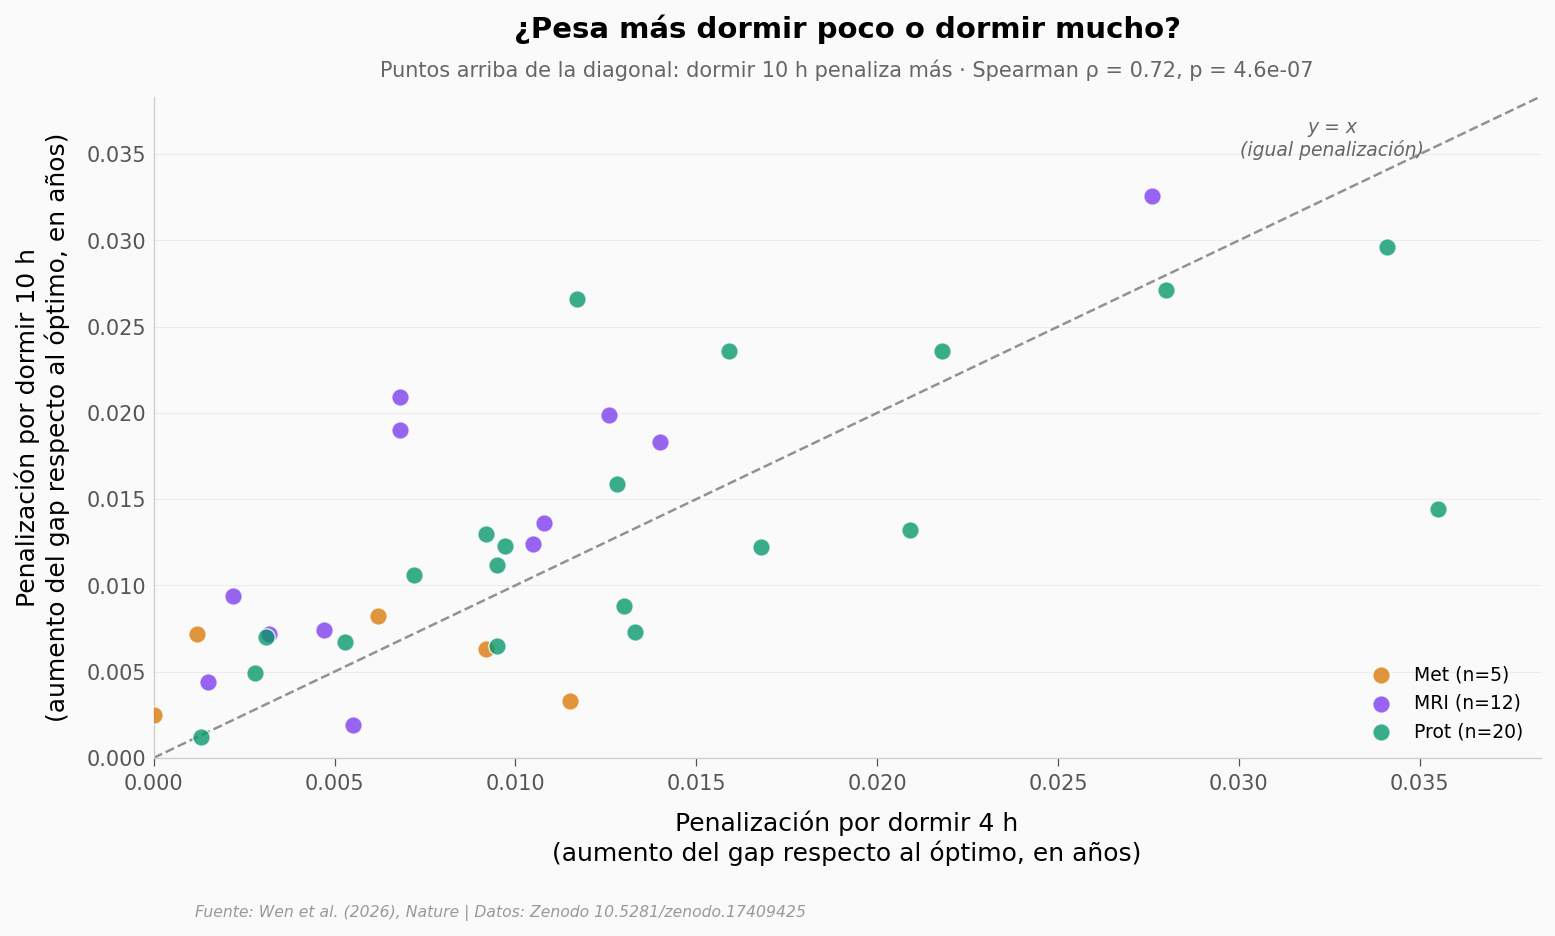


Combinaciones (n=37):
  Dormir 10 h penaliza más que 4 h: 25
  Dormir 4 h penaliza más que 10 h: 12
  Ratio promedio 4h/10h: 0.88
  → < 1 = dormir 10 h en promedio penaliza más


In [4]:
# Asimetría de la U: penalización por desviarse a 4h vs a 10h
fig, ax = plt.subplots(figsize=(10.5, 6))

# Estadística robusta (Spearman — no asume normalidad)
from scipy import stats as scstats
rho, p_val = scstats.spearmanr(df_u["penalizacion_4h"], df_u["penalizacion_10h"])

for tech in tech_order:
    sub = df_u[df_u["tecnologia"]==tech]
    ax.scatter(sub["penalizacion_4h"], sub["penalizacion_10h"],
               color=tech_colors[tech], s=70, alpha=0.78,
               edgecolors="white", linewidths=0.7, zorder=5,
               label=f"{tech} (n={len(sub)})")

# Diagonal 1:1 — penalizaciones equivalentes
lim_max = float(max(df_u["penalizacion_4h"].max(), df_u["penalizacion_10h"].max())) * 1.08
ax.plot([0, lim_max], [0, lim_max], color="#666666", linestyle="--",
        linewidth=1.2, alpha=0.7, zorder=2)
ax.text(lim_max*0.85, lim_max*0.91, "y = x\n(igual penalización)",
        fontsize=9, color="#666666", style="italic", ha="center")

ax.set_xlim(0, lim_max)
ax.set_ylim(0, lim_max)
ax.set_xlabel("Penalización por dormir 4 h\n(aumento del gap respecto al óptimo, en años)")
ax.set_ylabel("Penalización por dormir 10 h\n(aumento del gap respecto al óptimo, en años)")
ax.set_title("¿Pesa más dormir poco o dormir mucho?", fontsize=14, fontweight="bold", pad=28)
ax.text(0.5, 1.03,
        f"Puntos arriba de la diagonal: dormir 10 h penaliza más · Spearman ρ = {rho:.2f}, p = {p_val:.1e}",
        transform=ax.transAxes, fontsize=10, color="#666666", ha="center")
ax.legend(fontsize=9, loc="lower right", framealpha=0.9)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color="#999999", style="italic")

plt.tight_layout()
plt.savefig("figuras/03_asimetria_penalizaciones.png", dpi=200, bbox_inches="tight")
plt.show()

# Cuantificar cuántos casos caen sobre/bajo la diagonal
mas_pesa_10h = int((df_u["penalizacion_10h"] > df_u["penalizacion_4h"]).sum())
mas_pesa_4h  = int((df_u["penalizacion_4h"]  > df_u["penalizacion_10h"]).sum())
print(f"\nCombinaciones (n=37):")
print(f"  Dormir 10 h penaliza más que 4 h: {mas_pesa_10h}")
print(f"  Dormir 4 h penaliza más que 10 h: {mas_pesa_4h}")
print(f"  Ratio promedio 4h/10h: {df_u['penalizacion_4h'].mean()/df_u['penalizacion_10h'].mean():.2f}")
print(f"  → < 1 = dormir 10 h en promedio penaliza más")


## ¿Y qué tan lejos están las 8 horas del óptimo real?

Los relojes individuales se mueven entre 4.85 h (sistema inmune femenino, metabolómica) y 8.12 h (riñón femenino, proteómica). La pregunta es qué tan extremas son las **8 horas** del consejo popular frente a esa distribución.


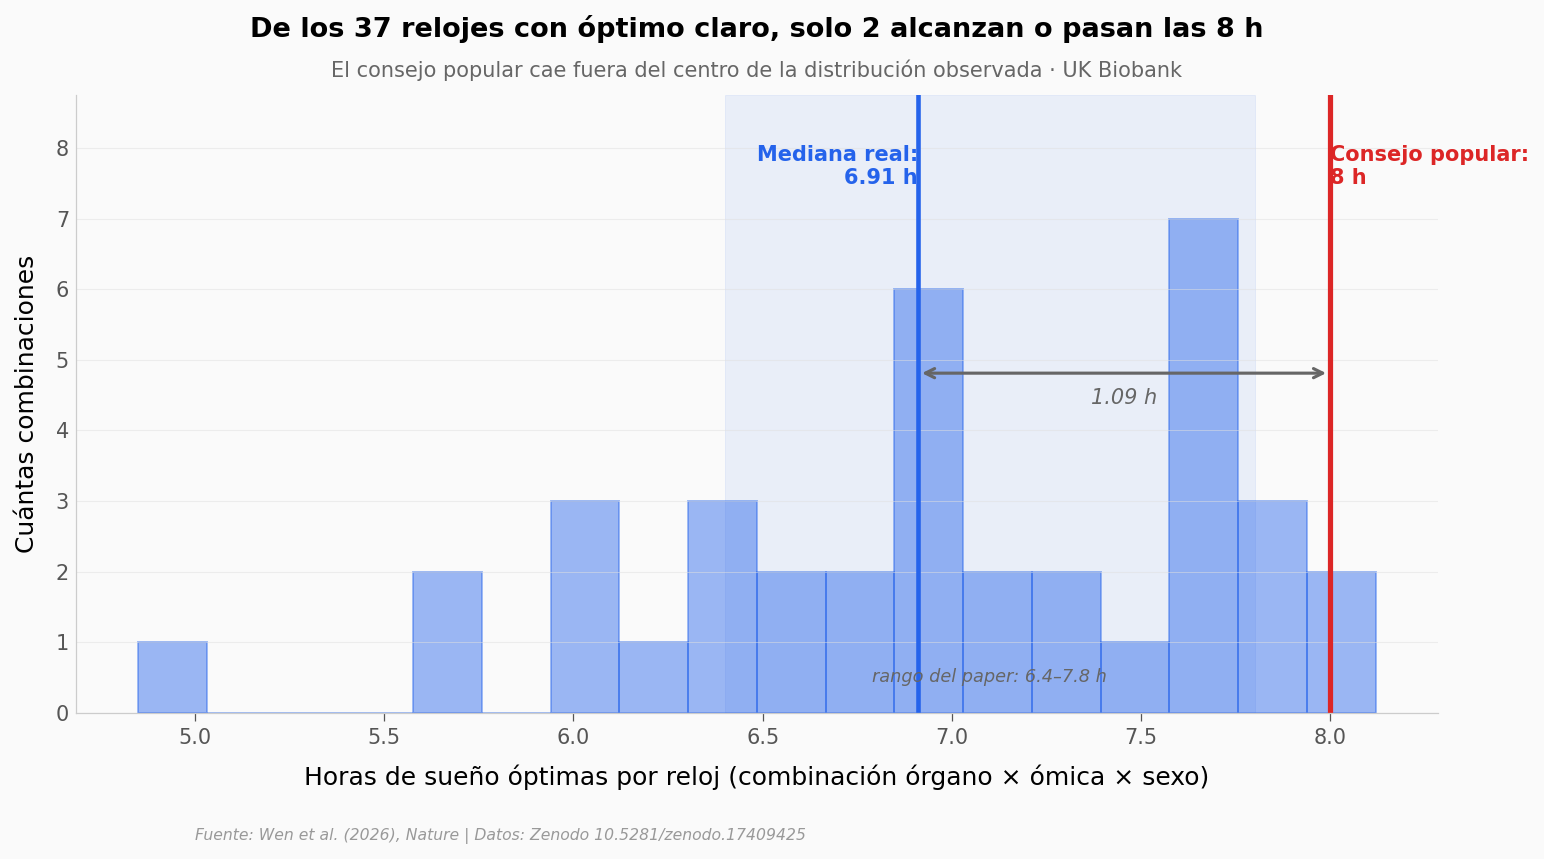


Resumen:
  Mediana óptima:      6.91 h
  IQR:                 6.48–7.64 h
  Combinaciones ≥ 8 h: 2 de 37 (5 %)


In [5]:
# Histograma de óptimos vs el titular de "8 horas"
fig, ax = plt.subplots(figsize=(10.5, 5.5))

valores = df_u["horas_optimo"].values
mediana_obs = float(np.median(valores))
n_total = len(valores)

n, bins, patches = ax.hist(valores, bins=18, color=COLOR_DATOS, alpha=0.45,
                           edgecolor=COLOR_DATOS, linewidth=0.9)
y_max = float(n.max()) * 1.25
ax.set_ylim(0, y_max)

# Línea mediana observada
ax.axvline(mediana_obs, color=COLOR_DATOS, linewidth=2.2)
ax.text(mediana_obs, y_max*0.92, f"Mediana real:\n{mediana_obs:.2f} h",
        color=COLOR_DATOS, fontsize=10, fontweight="bold",
        ha="right", va="top")

# Línea "8 horas"
ax.axvline(HORAS_TITULAR, color=COLOR_ALERTA, linewidth=2.5)
ax.text(HORAS_TITULAR, y_max*0.92, f"Consejo popular:\n{HORAS_TITULAR:.0f} h",
        color=COLOR_ALERTA, fontsize=10, fontweight="bold",
        ha="left", va="top")

# Flecha bidireccional entre ambas
ax.annotate("", xy=(HORAS_TITULAR, y_max*0.55), xytext=(mediana_obs, y_max*0.55),
            arrowprops=dict(arrowstyle="<->", color="#666666", lw=1.5))
ax.text((mediana_obs+HORAS_TITULAR)/2, y_max*0.5, f"{HORAS_TITULAR-mediana_obs:.2f} h",
        fontsize=10, color="#666666", ha="center", style="italic")

# Banda del rango del paper
ax.axvspan(RANGO_PAPER_MIN, RANGO_PAPER_MAX, color=COLOR_DATOS, alpha=0.08, zorder=1)
ax.text((RANGO_PAPER_MIN+RANGO_PAPER_MAX)/2, y_max*0.05,
        f"rango del paper: {RANGO_PAPER_MIN}–{RANGO_PAPER_MAX} h",
        fontsize=8.5, color="#666666", style="italic", ha="center")

n_por_encima_8 = int((valores >= HORAS_TITULAR).sum())
ax.set_xlabel("Horas de sueño óptimas por reloj (combinación órgano × ómica × sexo)")
ax.set_ylabel("Cuántas combinaciones")
ax.set_title(f"De los {n_total} relojes con óptimo claro, solo {n_por_encima_8} alcanzan o pasan las 8 h",
             fontsize=13, fontweight="bold", pad=28)
ax.text(0.5, 1.03, "El consejo popular cae fuera del centro de la distribución observada · UK Biobank",
        transform=ax.transAxes, fontsize=10, color="#666666", ha="center")
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color="#999999", style="italic")

plt.tight_layout()
plt.savefig("figuras/04_distribucion_optimos_vs_8h.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"\nResumen:")
print(f"  Mediana óptima:      {mediana_obs:.2f} h")
print(f"  IQR:                 {np.percentile(valores,25):.2f}–{np.percentile(valores,75):.2f} h")
print(f"  Combinaciones ≥ 8 h: {n_por_encima_8} de {n_total} ({100*n_por_encima_8/n_total:.0f} %)")


## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|---|---|---|
| El sueño óptimo varía por órgano y por ómica | ✅ | Mediana 6.91 h, IQR 6.48–7.64 h sobre 37 combinaciones con U interior. Diferencias claras entre Met (6.12 h), MRI (6.70 h) y Prot (7.61 h) |
| Las dos lentes sobre el cerebro discrepan ~1.3 h | ✅ | MRI cerebro: 6.42–6.48 h. Prot cerebro: 7.70–7.82 h. Diferencia consistente en ambos sexos |
| Sexo apenas mueve la mediana global | ✅ | Mediana femenina 6.97 h vs masculina 6.91 h (≈ 4 min) — la variación que importa está entre órganos y ómicas |
| Dormir 10 h tiende a penalizar más que dormir 4 h | ⚠️ | Ratio promedio 4h/10h = 0.88 (asimetría leve). Vale como tendencia descriptiva, no como hallazgo principal del paper |
| Las 8 h del consejo popular caen fuera del rango óptimo del paper | ✅ | Solo 2 de 37 combinaciones tienen óptimo ≥ 8 h (5 %). Rango del paper: 6.4–7.8 h |
| Dormir mal causa envejecimiento de órganos | ❌ | El paper explícitamente *no descarta causalidad inversa* (mendelian randomization). Solo asociaciones |

> **Limitaciones:** (1) Sueño *auto-reportado* — sesgo de recall y disociación con tiempo real dormido. (2) UK Biobank no representa población global. (3) Los GAM dan curvas suavizadas sobre la cohorte completa, no trayectorias individuales. (4) Cohort middle-late life (37–84 años) — extrapolación a otras edades injustificada. (5) Asociaciones poblacionales: el óptimo de tu reloj no se sigue de la mediana de la cohorte.


## Ahora tú

Tres preguntas que puedes explorar cambiando una línea de código:

1. **¿Qué órgano es más "sensible" al sueño?** Pista: ordena `optimos` por la suma `penalizacion_4h + penalizacion_10h`. ¿Quién encabeza la lista?
2. **¿Cambian los óptimos si filtras solo Proteómica?** Pista: filtra `df_u[df_u["tecnologia"]=="Prot"]` y vuelve a mirar la mediana — ¿se acerca o se aleja de las 8 h?
3. **¿En qué órgano la diferencia hombre-mujer es mayor?** Pista: `optimos.pivot_table(index=["organo","tecnologia"], columns="sexo", values="horas_optimo")` y calcula la diferencia absoluta.


In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: ¿qué órgano es más sensible al sueño?
df_sens = df_u.copy()
df_sens["sensibilidad"] = df_sens["penalizacion_4h"] + df_sens["penalizacion_10h"]
top5 = df_sens.sort_values("sensibilidad", ascending=False).head(5)

print("Top 5 relojes más sensibles a desviarse del óptimo (suma de penalización en 4 h y 10 h):\n")
print(top5[["organo","tecnologia","sexo","horas_optimo","penalizacion_4h","penalizacion_10h","sensibilidad"]].to_string(index=False))

# Pregunta 2: ¿qué pasa si solo miras Proteómica?
mediana_prot = df_u[df_u["tecnologia"]=="Prot"]["horas_optimo"].median()
print(f"\nMediana solo Proteómica: {mediana_prot:.2f} h — más cerca del 'consejo popular' de 8 h")


Top 5 relojes más sensibles a desviarse del óptimo (suma de penalización en 4 h y 10 h):

   organo tecnologia sexo  horas_optimo  penalizacion_4h  penalizacion_10h  sensibilidad
    Brain       Prot male          7.70           0.0341            0.0296        0.0637
  Adipose        MRI male          6.91           0.0276            0.0326        0.0602
Pulmonary       Prot male          7.03           0.0280            0.0271        0.0551
Endocrine       Prot male          7.27           0.0355            0.0144        0.0499
    Heart       Prot male          6.97           0.0218            0.0236        0.0454

Mediana solo Proteómica: 7.61 h — más cerca del 'consejo popular' de 8 h


---

## Fuentes

**Paper**: [Sleep chart of biological ageing clocks in middle and late life](https://doi.org/10.1038/s41586-026-10524-5)  
*Nature, 2026-05-13*

**Datos**: [SleepChart source data for figures and R script](https://doi.org/10.5281/zenodo.17409425)  
*Zenodo, CC-BY 4.0*

**Referencias citadas**: [SleepChart-R v0.1 (Wen, J.)](https://github.com/anbai106/SleepChart) — pipeline R original

*17 afirmaciones verificadas contra estas fuentes*

---

**Reproducibilidad:** Los datos `curvas_u_sueno_edad.csv` y `optimo_sueno_por_organo.csv` se derivan del repositorio Zenodo (CC-BY 4.0) asociado al paper. Pipeline R original: [SleepChart-R](https://github.com/anbai106/SleepChart).

**Repositorio del Lab:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) — todo el código es público y reproducible. *Issues* y *pull requests* bienvenidos.
